✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🧠 正在生成马尔可夫演化态势...
📡 正在合成含同步头的 IQ 波形...


  5%|▌         | 157/3000 [00:00<00:08, 318.56it/s]

100%|██████████| 3000/3000 [00:12<00:00, 239.22it/s]


✅ 数据集与同步参数已保存至: ./sim_dataset_v6_4


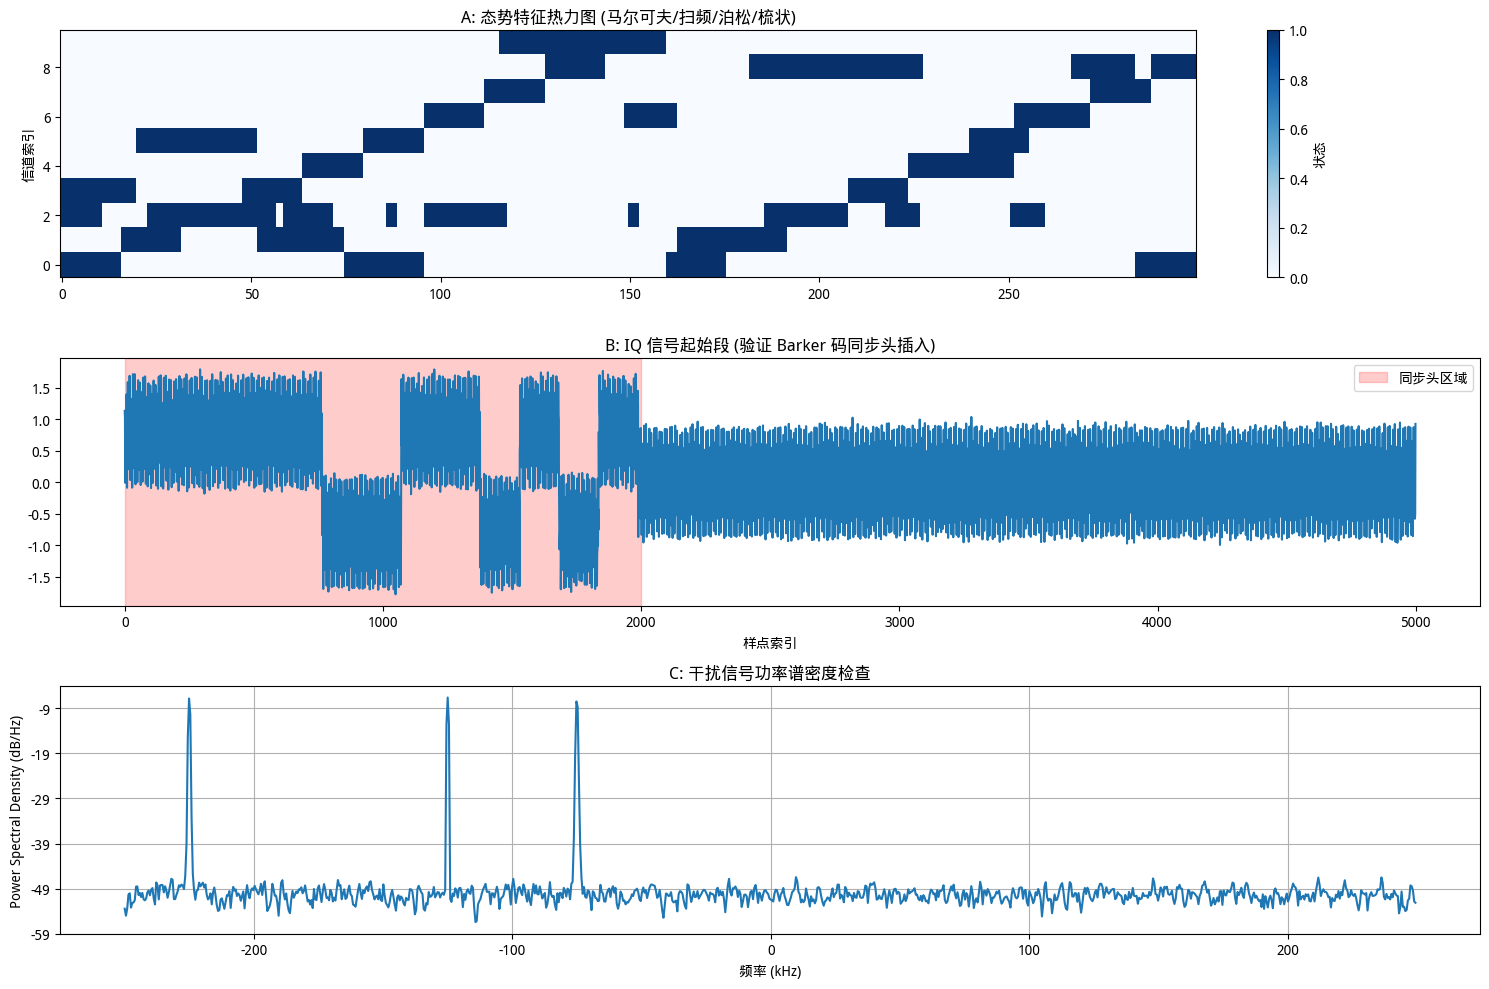

In [2]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import medfilt2d
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 学术级参数配置 (对齐实测参数) ====================
class AcademicSimConfig:
    def __init__(self):
        # 物理层参数
        self.fs = 500e3           # 采样率 500kHz
        self.num_channels = 10     # 10个子信道
        self.time_step_s = 0.05    # 50ms 态势步长
        self.samples_per_step = int(self.fs * self.time_step_s) # 25000样点
        self.freq_centers = np.linspace(-225e3, 225e3, 10) # 信道中心频率
        
        # --- 新增：同步与时间戳配置 ---
        # 使用 13 位巴克码作为同步序列
        self.barker = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]) 
        self.sync_samples = 2000   # 同步头占据的总样点数 (含填充)
        
        # 预测模型参数
        self.window_size = 12      # Transformer 输入窗口
        self.total_steps = 3000    # 总演化步数 (约 150 秒数据)
        
        # 随机过程控制参数
        self.markov_p_start = 0.05 
        self.markov_p_stay = 0.90  
        self.poisson_lambda = 20   
        
        self.save_dir = "./sim_dataset_v6_4"
        os.makedirs(self.save_dir, exist_ok=True)

# ==================== 2. 符合学术物理规律的演化矩阵生成 ====================
def generate_academic_evolution(cfg):
    """生成符合马尔可夫和物理约束的态势矩阵"""
    matrix = np.zeros((cfg.total_steps, cfg.num_channels))
    
    # 模式 A: 扫频干扰 (Sweeping)
    sweep_period = 160 
    for t in range(cfg.total_steps):
        ch = (t % sweep_period) // (sweep_period // cfg.num_channels)
        matrix[t, int(ch)] = 1.0

    # 模式 B: 马尔可夫单频干扰 (Markov)
    state = 0
    target_ch = 2
    for t in range(cfg.total_steps):
        if state == 0:
            state = 1 if np.random.rand() < cfg.markov_p_start else 0
        else:
            state = 1 if np.random.rand() < cfg.markov_p_stay else 0
        if state == 1: matrix[t, target_ch] = 1.0

    # 模式 C: 泊松分布跳频干扰 (Poisson)
    curr_hop_ch = 8
    dwell_time = 0
    for t in range(cfg.total_steps):
        if dwell_time <= 0:
            curr_hop_ch = np.random.randint(0, cfg.num_channels)
            dwell_time = np.random.poisson(cfg.poisson_lambda)
        matrix[t, curr_hop_ch] = 1.0
        dwell_time -= 1

    # 模式 D: 固定梳状干扰 (Static Comb)
    matrix[500:2500, [0, 9]] = 1.0 
    
    return medfilt2d(matrix, kernel_size=(3, 1))

# ==================== 3. 增强型信号合成 (含同步头与时间戳) ====================
def synthesize_waveform_with_sync(cfg, sit_vector, step_idx):
    """合成带有同步标志和物理态势的 IQ 信号"""
    t_step = np.arange(cfg.samples_per_step) / cfg.fs
    waveform = np.zeros(cfg.samples_per_step, dtype=np.complex64)
    
    # --- A. 添加同步头 (仅在第 0 步或每隔一定步数添加) ---
    # 如果是第一帧，在开头插入强相关的巴克码序列，用于实测对齐起点
    if step_idx == 0:
        sync_pulse = np.repeat(cfg.barker, cfg.sync_samples // len(cfg.barker))
        waveform[:len(sync_pulse)] = sync_pulse * 0.8 # 增强同步头强度
    
    # --- B. 合成干扰信号 ---
    for ch_idx, active in enumerate(sit_vector):
        if active:
            f = cfg.freq_centers[ch_idx]
            # 这里的 0.4 振幅对应实测时的功率量级
            waveform += 0.4 * np.exp(1j * (2 * np.pi * f * t_step + np.random.rand() * 2 * np.pi))
            
    # 添加噪声底
    noise = (np.random.normal(0, 0.05, cfg.samples_per_step) + 
             1j * np.random.normal(0, 0.05, cfg.samples_per_step))
    return waveform + noise

# ==================== 4. 执行全流程生成 ====================
def main_v6_4():
    cfg = AcademicSimConfig()
    
    # 1. 态势规律生成 (真值)
    print("🧠 正在生成马尔可夫演化态势...")
    sit_matrix = generate_academic_evolution(cfg)
    
    # 2. IQ 波形合成 (含同步逻辑)
    print("📡 正在合成含同步头的 IQ 波形...")
    full_iq = []
    timestamps = []
    
    for t in tqdm(range(cfg.total_steps)):
        # 生成每一帧的 IQ 信号
        full_iq.append(synthesize_waveform_with_sync(cfg, sit_matrix[t], t))
        # 记录绝对时间戳 (单位: 秒)
        timestamps.append(t * cfg.time_step_s)
    
    # 导出 .dat 文件 (USRP 发射源)
    iq_data = np.concatenate(full_iq).astype(np.complex64)
    iq_data.tofile(os.path.join(cfg.save_dir, "tx_sync_v6_4.dat"))
    
    # 3. 构建 H5 数据集 (含时间戳对齐)
    X, Y = [], []
    for i in range(len(sit_matrix) - cfg.window_size):
        X.append(sit_matrix[i : i + cfg.window_size])
        Y.append(sit_matrix[i + cfg.window_size])
    
    with h5py.File(os.path.join(cfg.save_dir, "academic_train_v6_4.h5"), 'w') as f:
        f.create_dataset("X", data=np.array(X))
        f.create_dataset("Y", data=np.array(Y))
        f.create_dataset("timestamps", data=np.array(timestamps[cfg.window_size:]))
        # 保存同步头位置信息供接收端使用
        f.attrs['sync_barker'] = cfg.barker
        print(f"✅ 数据集与同步参数已保存至: {cfg.save_dir}")

    # ==================== 5. 可视化报告 (不可删除) ====================
    plt.figure(figsize=(15, 10))
    
    # A. 态势演化图
    plt.subplot(3, 1, 1)
    plt.imshow(sit_matrix[:300].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("A: 态势特征热力图 (马尔可夫/扫频/泊松/梳状)", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    plt.colorbar(label="状态")

    # B. 同步头时域特征 (验证同步头是否存在)
    plt.subplot(3, 1, 2)
    plt.plot(np.real(iq_data[:5000]))
    plt.axvspan(0, cfg.sync_samples, color='red', alpha=0.2, label='同步头区域')
    plt.title("B: IQ 信号起始段 (验证 Barker 码同步头插入)", fontsize=12, fontweight='bold')
    plt.xlabel("样点索引")
    plt.legend()

    # C. 频谱分析
    plt.subplot(3, 1, 3)
    plt.psd(iq_data[cfg.sync_samples : cfg.sync_samples + 10000], NFFT=1024, Fs=cfg.fs/1e3)
    plt.title("C: 干扰信号功率谱密度检查", fontsize=12, fontweight='bold')
    plt.xlabel("频率 (kHz)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "academic_sync_check_v6_4.png"), dpi=300)
    plt.show()

if __name__ == "__main__":
    main_v6_4()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🧠 正在生成 5 种干扰模式的长时演化态势...
📡 正在合成含同步头的原始波形文件...


100%|██████████| 4000/4000 [00:18<00:00, 218.29it/s]


💾 正在构建多任务长时预测 H5 数据集...
✅ 长时预测数据集已成功保存至: ./sim_dataset_v6_5


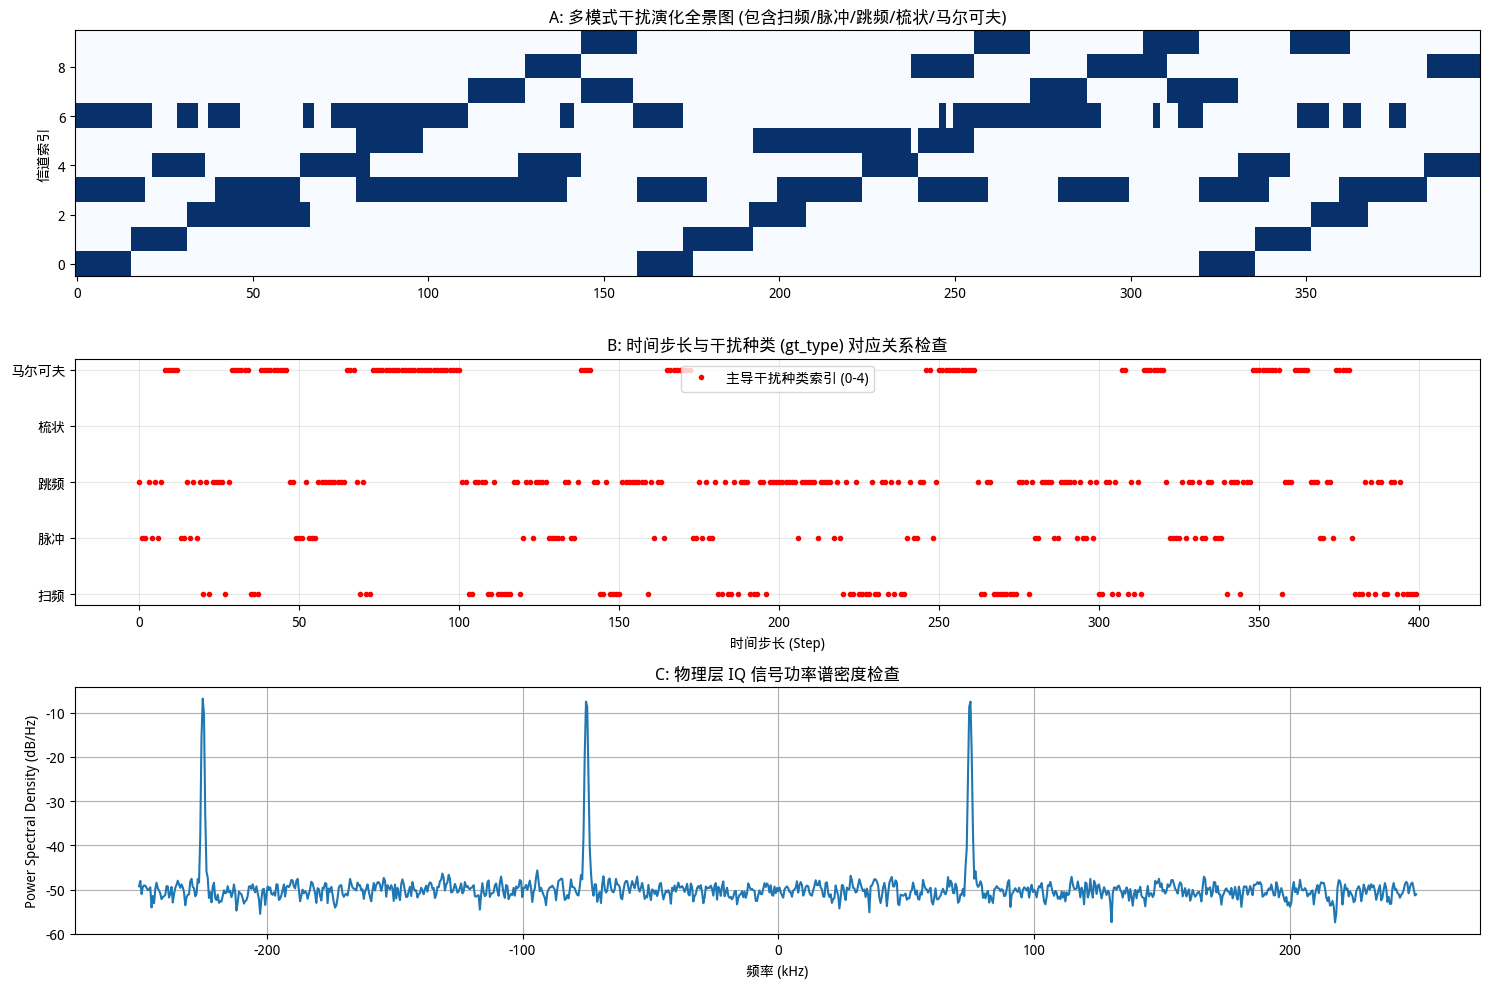

In [3]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import medfilt2d
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 学术级参数配置 (对齐实测参数) ====================
class AcademicSimConfig:
    def __init__(self):
        # 物理层参数
        self.fs = 500e3           # 采样率 500kHz
        self.num_channels = 10     # 10个子信道
        self.time_step_s = 0.05    # 50ms 态势步长
        self.samples_per_step = int(self.fs * self.time_step_s) # 25000样点
        self.freq_centers = np.linspace(-225e3, 225e3, 10) # 信道中心频率
        
        # 同步配置
        self.barker = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]) 
        self.sync_samples = 2000   
        
        # 预测模型参数
        self.window_size = 12      # Transformer 历史输入窗口 (600ms)
        self.horizon = 10          # 长时预测未来窗口 (500ms)
        self.total_steps = 4000    # 增加步数以补偿长时预测所需的后续数据
        
        # 随机过程控制参数
        self.markov_p_start = 0.05 
        self.markov_p_stay = 0.90  
        self.poisson_lambda = 20   
        
        self.save_dir = "./sim_dataset_v6_5"
        os.makedirs(self.save_dir, exist_ok=True)

# ==================== 2. 符合学术规律的演化矩阵与种类标签生成 ====================
def generate_academic_evolution(cfg):
    """生成包含 5 种干扰的一致性演化矩阵和分类索引"""
    matrix = np.zeros((cfg.total_steps, cfg.num_channels))
    type_labels = np.zeros(cfg.total_steps, dtype=np.int32) # 记录每步的主导种类 (0-4)
    
    # 模式 0: 线性扫频干扰 (Sweeping)
    sweep_period = 160 
    for t in range(cfg.total_steps):
        ch = (t % sweep_period) // (sweep_period // cfg.num_channels)
        matrix[t, int(ch)] = 1.0
        type_labels[t] = 0 # 扫频标记为 0

    # 模式 1: 周期脉冲干扰 (Pulse)
    for t in range(cfg.total_steps):
        if (t // 20) % 2 == 0:
            matrix[t, 3] = 1.0
            type_labels[t] = 1 # 脉冲标记为 1

    # 模式 2: 泊松分布跳频干扰 (Hopping)
    curr_hop_ch = 8
    dwell_time = 0
    for t in range(cfg.total_steps):
        if dwell_time <= 0:
            curr_hop_ch = np.random.randint(0, cfg.num_channels)
            dwell_time = np.random.poisson(cfg.poisson_lambda)
        matrix[t, curr_hop_ch] = 1.0
        # 如果是跳频期间，覆盖之前的标记
        if np.random.rand() > 0.5: type_labels[t] = 2 
        dwell_time -= 1

    # 模式 3: 固定梳状干扰 (Static Comb)
    for t in range(500, 3500):
        matrix[t, [0, 9]] = 1.0
        if t % 5 == 0: type_labels[t] = 3

    # 模式 4: 马尔可夫单频干扰 (Markov)
    state = 0
    for t in range(cfg.total_steps):
        if state == 0:
            state = 1 if np.random.rand() < cfg.markov_p_start else 0
        else:
            state = 1 if np.random.rand() < cfg.markov_p_stay else 0
        if state == 1: 
            matrix[t, 6] = 1.0
            type_labels[t] = 4

    # 滤波平滑
    matrix = medfilt2d(matrix, kernel_size=(3, 1))
    return matrix, type_labels

# ==================== 3. 原始信号合成 (保持不变) ====================
def synthesize_waveform_with_sync(cfg, sit_vector, step_idx):
    t_step = np.arange(cfg.samples_per_step) / cfg.fs
    waveform = np.zeros(cfg.samples_per_step, dtype=np.complex64)
    if step_idx == 0:
        sync_pulse = np.repeat(cfg.barker, cfg.sync_samples // len(cfg.barker))
        waveform[:len(sync_pulse)] = sync_pulse * 0.8
    for ch_idx, active in enumerate(sit_vector):
        if active:
            f = cfg.freq_centers[ch_idx]
            waveform += 0.4 * np.exp(1j * (2 * np.pi * f * t_step + np.random.rand() * 2 * np.pi))
    noise = (np.random.normal(0, 0.05, cfg.samples_per_step) + 
             1j * np.random.normal(0, 0.05, cfg.samples_per_step))
    return waveform + noise

# ==================== 4. 主运行程序 (改造成长时预测 H5 结构) ====================
def main_v6_5():
    cfg = AcademicSimConfig()
    
    # 1. 态势规律与种类生成
    print("🧠 正在生成 5 种干扰模式的长时演化态势...")
    sit_matrix, type_indices = generate_academic_evolution(cfg)
    
    # 2. IQ 波形合成 (用于实测发射)
    print("📡 正在合成含同步头的原始波形文件...")
    full_iq = []
    for t in tqdm(range(cfg.total_steps)):
        full_iq.append(synthesize_waveform_with_sync(cfg, sit_matrix[t], t))
    
    iq_data = np.concatenate(full_iq).astype(np.complex64)
    iq_data.tofile(os.path.join(cfg.save_dir, "tx_sync_long_horizon_v6_5.dat"))
    
    # 3. 构建长时预测 H5 数据集
    print("💾 正在构建多任务长时预测 H5 数据集...")
    X, Y_horizon, gt_type = [], [], []
    
    # 滑动窗口构建：确保有足够的数据做未来 10 步的标签
    for i in range(len(sit_matrix) - cfg.window_size - cfg.horizon):
        # 输入：过去 12 步 (600ms)
        X.append(sit_matrix[i : i + cfg.window_size])
        # 标签 A：未来 10 步的长时轨迹 (Horizon=10, Channels=10)
        Y_horizon.append(sit_matrix[i + cfg.window_size : i + cfg.window_size + cfg.horizon])
        # 标签 B：下一时刻的主导干扰种类 (0-4)
        gt_type.append(type_indices[i + cfg.window_size])
    
    with h5py.File(os.path.join(cfg.save_dir, "academic_long_horizon_v6_5.h5"), 'w') as f:
        f.create_dataset("X", data=np.array(X))                  # 形状: (N, 12, 10)
        f.create_dataset("Y_horizon", data=np.array(Y_horizon))  # 形状: (N, 10, 10)
        f.create_dataset("gt_type", data=np.array(gt_type))      # 形状: (N,)
        f.attrs['horizon_steps'] = cfg.horizon
        f.attrs['time_step_s'] = cfg.time_step_s
        print(f"✅ 长时预测数据集已成功保存至: {cfg.save_dir}")

    # ==================== 5. 可视化报告 (不可删除) ====================
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.imshow(sit_matrix[:400].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("A: 多模式干扰演化全景图 (包含扫频/脉冲/跳频/梳状/马尔可夫)", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    
    plt.subplot(3, 1, 2)
    plt.plot(type_indices[:400], 'r.', label='主导干扰种类索引 (0-4)')
    plt.title("B: 时间步长与干扰种类 (gt_type) 对应关系检查", fontsize=12, fontweight='bold')
    plt.xlabel("时间步长 (Step)")
    plt.yticks(range(5), ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.psd(iq_data[10000:20000], NFFT=1024, Fs=cfg.fs/1e3)
    plt.title("C: 物理层 IQ 信号功率谱密度检查", fontsize=12, fontweight='bold')
    plt.xlabel("频率 (kHz)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "v6_5_academic_report.png"), dpi=300)
    plt.show()

if __name__ == "__main__":
    main_v6_5()

✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🧠 正在生成 5 种干扰模式的长时演化态势...
📡 正在合成含同步头的原始波形文件...


100%|██████████| 4000/4000 [00:18<00:00, 213.61it/s]


💾 正在构建多任务长时预测 H5 数据集...
✅ 长时预测数据集已成功保存至: ./sim_dataset_v6_5


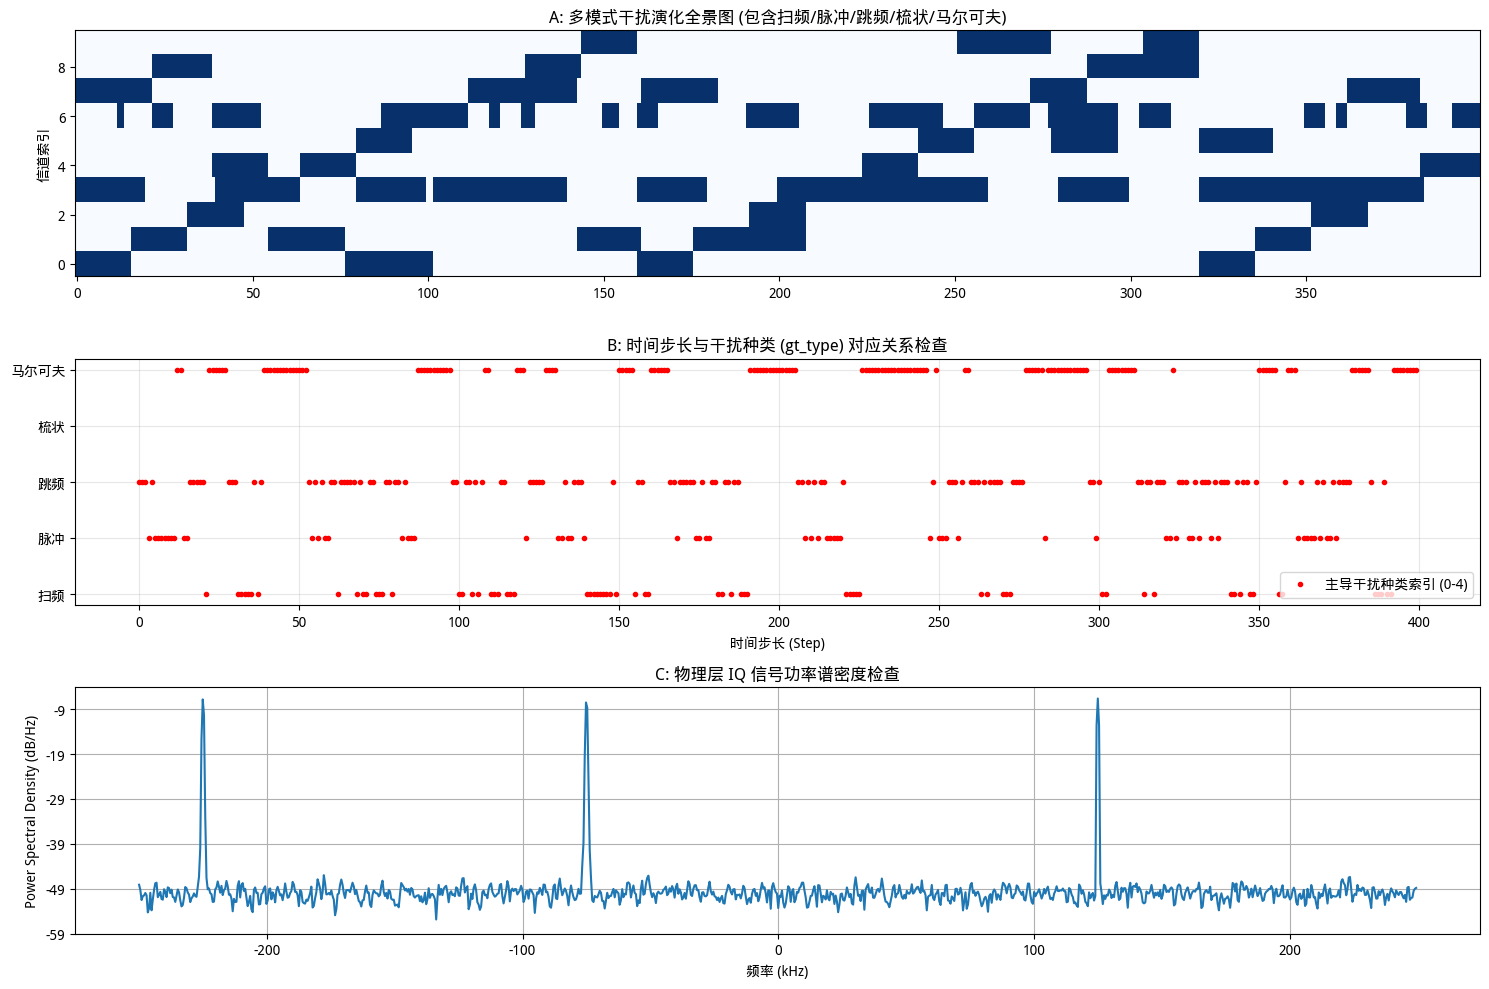

In [1]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import medfilt2d
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 学术级参数配置 (对齐实测参数) ====================
class AcademicSimConfig:
    def __init__(self):
        # 物理层参数
        self.fs = 500e3           # 采样率 500kHz
        self.num_channels = 10     # 10个子信道
        self.time_step_s = 0.05    # 50ms 态势步长
        self.samples_per_step = int(self.fs * self.time_step_s) # 25000样点
        self.freq_centers = np.linspace(-225e3, 225e3, 10) # 信道中心频率
        
        # 同步配置
        self.barker = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]) 
        self.sync_samples = 2000   
        
        # 预测模型参数
        self.window_size = 12      # Transformer 历史输入窗口 (600ms)
        self.horizon = 10          # 长时预测未来窗口 (500ms)
        self.total_steps = 4000    # 增加步数以补偿长时预测所需的后续数据
        
        # 随机过程控制参数
        self.markov_p_start = 0.05 
        self.markov_p_stay = 0.90  
        self.poisson_lambda = 20   
        
        self.save_dir = "./sim_dataset_v6_5"
        os.makedirs(self.save_dir, exist_ok=True)

# ==================== 2. 符合学术规律的演化矩阵与种类标签生成 ====================
def generate_academic_evolution(cfg):
    """生成包含 5 种干扰的一致性演化矩阵和分类索引"""
    matrix = np.zeros((cfg.total_steps, cfg.num_channels))
    type_labels = np.zeros(cfg.total_steps, dtype=np.int32) # 记录每步的主导种类 (0-4)
    
    # 模式 0: 线性扫频干扰 (Sweeping)
    sweep_period = 160 
    for t in range(cfg.total_steps):
        ch = (t % sweep_period) // (sweep_period // cfg.num_channels)
        matrix[t, int(ch)] = 1.0
        type_labels[t] = 0 # 扫频标记为 0

    # 模式 1: 周期脉冲干扰 (Pulse)
    for t in range(cfg.total_steps):
        if (t // 20) % 2 == 0:
            matrix[t, 3] = 1.0
            type_labels[t] = 1 # 脉冲标记为 1

    # 模式 2: 泊松分布跳频干扰 (Hopping)
    curr_hop_ch = 8
    dwell_time = 0
    for t in range(cfg.total_steps):
        if dwell_time <= 0:
            curr_hop_ch = np.random.randint(0, cfg.num_channels)
            dwell_time = np.random.poisson(cfg.poisson_lambda)
        matrix[t, curr_hop_ch] = 1.0
        # 如果是跳频期间，覆盖之前的标记
        if np.random.rand() > 0.5: type_labels[t] = 2 
        dwell_time -= 1

    # 模式 3: 固定梳状干扰 (Static Comb)
    for t in range(500, 3500):
        matrix[t, [0, 9]] = 1.0
        if t % 5 == 0: type_labels[t] = 3

    # 模式 4: 马尔可夫单频干扰 (Markov)
    state = 0
    for t in range(cfg.total_steps):
        if state == 0:
            state = 1 if np.random.rand() < cfg.markov_p_start else 0
        else:
            state = 1 if np.random.rand() < cfg.markov_p_stay else 0
        if state == 1: 
            matrix[t, 6] = 1.0
            type_labels[t] = 4

    # 滤波平滑
    matrix = medfilt2d(matrix, kernel_size=(3, 1))
    return matrix, type_labels

# ==================== 3. 原始信号合成 (保持不变) ====================
def synthesize_waveform_with_sync(cfg, sit_vector, step_idx):
    t_step = np.arange(cfg.samples_per_step) / cfg.fs
    waveform = np.zeros(cfg.samples_per_step, dtype=np.complex64)
    if step_idx == 0:
        sync_pulse = np.repeat(cfg.barker, cfg.sync_samples // len(cfg.barker))
        waveform[:len(sync_pulse)] = sync_pulse * 0.8
    for ch_idx, active in enumerate(sit_vector):
        if active:
            f = cfg.freq_centers[ch_idx]
            waveform += 0.4 * np.exp(1j * (2 * np.pi * f * t_step + np.random.rand() * 2 * np.pi))
    noise = (np.random.normal(0, 0.05, cfg.samples_per_step) + 
             1j * np.random.normal(0, 0.05, cfg.samples_per_step))
    return waveform + noise

# ==================== 4. 主运行程序 (改造成长时预测 H5 结构) ====================
def main_v6_5():
    cfg = AcademicSimConfig()
    
    # 1. 态势规律与种类生成
    print("🧠 正在生成 5 种干扰模式的长时演化态势...")
    sit_matrix, type_indices = generate_academic_evolution(cfg)
    
    # 2. IQ 波形合成 (用于实测发射)
    print("📡 正在合成含同步头的原始波形文件...")
    full_iq = []
    for t in tqdm(range(cfg.total_steps)):
        full_iq.append(synthesize_waveform_with_sync(cfg, sit_matrix[t], t))
    
    iq_data = np.concatenate(full_iq).astype(np.complex64)
    iq_data.tofile(os.path.join(cfg.save_dir, "tx_sync_long_horizon_v6_5.dat"))
    
    # 3. 构建长时预测 H5 数据集
    print("💾 正在构建多任务长时预测 H5 数据集...")
    X, Y_horizon, gt_type = [], [], []
    
    # 滑动窗口构建：确保有足够的数据做未来 10 步的标签
    for i in range(len(sit_matrix) - cfg.window_size - cfg.horizon):
        # 输入：过去 12 步 (600ms)
        X.append(sit_matrix[i : i + cfg.window_size])
        # 标签 A：未来 10 步的长时轨迹 (Horizon=10, Channels=10)
        Y_horizon.append(sit_matrix[i + cfg.window_size : i + cfg.window_size + cfg.horizon])
        # 标签 B：下一时刻的主导干扰种类 (0-4)
        gt_type.append(type_indices[i + cfg.window_size])
    
    with h5py.File(os.path.join(cfg.save_dir, "academic_long_horizon_v6_5.h5"), 'w') as f:
        f.create_dataset("X", data=np.array(X))                  # 形状: (N, 12, 10)
        f.create_dataset("Y_horizon", data=np.array(Y_horizon))  # 形状: (N, 10, 10)
        f.create_dataset("gt_type", data=np.array(gt_type))      # 形状: (N,)
        f.attrs['horizon_steps'] = cfg.horizon
        f.attrs['time_step_s'] = cfg.time_step_s
        print(f"✅ 长时预测数据集已成功保存至: {cfg.save_dir}")

    # ==================== 5. 可视化报告 (不可删除) ====================
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.imshow(sit_matrix[:400].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("A: 多模式干扰演化全景图 (包含扫频/脉冲/跳频/梳状/马尔可夫)", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    
    plt.subplot(3, 1, 2)
    plt.plot(type_indices[:400], 'r.', label='主导干扰种类索引 (0-4)')
    plt.title("B: 时间步长与干扰种类 (gt_type) 对应关系检查", fontsize=12, fontweight='bold')
    plt.xlabel("时间步长 (Step)")
    plt.yticks(range(5), ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.psd(iq_data[10000:20000], NFFT=1024, Fs=cfg.fs/1e3)
    plt.title("C: 物理层 IQ 信号功率谱密度检查", fontsize=12, fontweight='bold')
    plt.xlabel("频率 (kHz)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "v6_5_academic_report.png"), dpi=300)
    plt.show()

if __name__ == "__main__":
    main_v6_5()

In [ ]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import medfilt2d
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 学术级参数配置 (对齐实测参数) ====================
class AcademicSimConfig:
    def __init__(self):
        # 物理层参数
        self.fs = 200e3           # 🔥 采样率已修正为 200kHz
        self.num_channels = 10     # 10个子信道
        self.time_step_s = 0.05    # 50ms 态势步长
        self.samples_per_step = int(self.fs * self.time_step_s) # 10,000样点 (200k * 0.05)
        
        # 🔥 修正：频率中心必须在 [-fs/2, fs/2] 范围内，即 [-100k, 100k]
        # 预留边缘保护带，设为 [-90k, 90k]
        self.freq_centers = np.linspace(-90e3, 90e3, 10) 
        
        # 同步配置
        self.barker = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]) 
        self.sync_samples = 2000   
        
        # 预测模型参数
        self.window_size = 12      # Transformer 历史输入窗口 (600ms)
        self.horizon = 10          # 长时预测未来窗口 (500ms)
        self.total_steps = 4000    # 步数
        
        # 随机过程控制参数
        self.markov_p_start = 0.05 
        self.markov_p_stay = 0.90  
        self.poisson_lambda = 20   
        
        self.save_dir = "./sim_dataset_v6_5"
        os.makedirs(self.save_dir, exist_ok=True)

# ==================== 2. 符合学术规律的演化矩阵与种类标签生成 ====================
def generate_academic_evolution(cfg):
    """生成包含 5 种干扰的一致性演化矩阵和分类索引"""
    matrix = np.zeros((cfg.total_steps, cfg.num_channels))
    type_labels = np.zeros(cfg.total_steps, dtype=np.int32) 
    
    # 模式 0: 线性扫频干扰 (Sweeping)
    sweep_period = 160 
    for t in range(cfg.total_steps):
        ch = (t % sweep_period) // (sweep_period // cfg.num_channels)
        matrix[t, int(ch)] = 1.0
        type_labels[t] = 0 

    # 模式 1: 周期脉冲干扰 (Pulse)
    for t in range(cfg.total_steps):
        if (t // 20) % 2 == 0:
            matrix[t, 3] = 1.0
            type_labels[t] = 1 

    # 模式 2: 泊松分布跳频干扰 (Hopping)
    curr_hop_ch = 8
    dwell_time = 0
    for t in range(cfg.total_steps):
        if dwell_time <= 0:
            curr_hop_ch = np.random.randint(0, cfg.num_channels)
            dwell_time = np.random.poisson(cfg.poisson_lambda)
        matrix[t, curr_hop_ch] = 1.0
        if np.random.rand() > 0.5: type_labels[t] = 2 
        dwell_time -= 1

    # 模式 3: 固定梳状干扰 (Static Comb)
    for t in range(500, 3500):
        matrix[t, [0, 9]] = 1.0
        if t % 5 == 0: type_labels[t] = 3

    # 模式 4: 马尔可夫单频干扰 (Markov)
    state = 0
    for t in range(cfg.total_steps):
        if state == 0:
            state = 1 if np.random.rand() < cfg.markov_p_start else 0
        else:
            state = 1 if np.random.rand() < cfg.markov_p_stay else 0
        if state == 1: 
            matrix[t, 6] = 1.0
            type_labels[t] = 4

    # 滤波平滑
    matrix = medfilt2d(matrix, kernel_size=(3, 1))
    return matrix, type_labels

# ==================== 3. 原始信号合成 (保持不变) ====================
def synthesize_waveform_with_sync(cfg, sit_vector, step_idx):
    t_step = np.arange(cfg.samples_per_step) / cfg.fs
    waveform = np.zeros(cfg.samples_per_step, dtype=np.complex64)
    if step_idx == 0:
        sync_pulse = np.repeat(cfg.barker, cfg.sync_samples // len(cfg.barker))
        waveform[:len(sync_pulse)] = sync_pulse * 0.8
    for ch_idx, active in enumerate(sit_vector):
        if active:
            f = cfg.freq_centers[ch_idx]
            waveform += 0.4 * np.exp(1j * (2 * np.pi * f * t_step + np.random.rand() * 2 * np.pi))
    noise = (np.random.normal(0, 0.05, cfg.samples_per_step) + 
             1j * np.random.normal(0, 0.05, cfg.samples_per_step))
    return waveform + noise

# ==================== 4. 主运行程序 (改造成长时预测 H5 结构) ====================
def main_v6_5():
    cfg = AcademicSimConfig()
    
    # 1. 态势规律与种类生成
    print("🧠 正在生成 5 种干扰模式的长时演化态势...")
    sit_matrix, type_indices = generate_academic_evolution(cfg)
    
    # 2. IQ 波形合成 (用于实测发射)
    print("📡 正在合成含同步头的原始波形文件...")
    full_iq = []
    for t in tqdm(range(cfg.total_steps)):
        full_iq.append(synthesize_waveform_with_sync(cfg, sit_matrix[t], t))
    
    iq_data = np.concatenate(full_iq).astype(np.complex64)
    # 🔥 文件名更新以体现采样率
    iq_data.tofile(os.path.join(cfg.save_dir, "tx_sync_long_horizon_v6_5_200k.dat"))
    
    # 3. 构建长时预测 H5 数据集
    print("💾 正在构建多任务长时预测 H5 数据集...")
    X, Y_horizon, gt_type = [], [], []
    
    for i in range(len(sit_matrix) - cfg.window_size - cfg.horizon):
        X.append(sit_matrix[i : i + cfg.window_size])
        Y_horizon.append(sit_matrix[i + cfg.window_size : i + cfg.window_size + cfg.horizon])
        gt_type.append(type_indices[i + cfg.window_size])
    
    # 🔥 保存文件名更新
    h5_filename = os.path.join(cfg.save_dir, "academic_long_horizon_v6_5_200k.h5")
    with h5py.File(h5_filename, 'w') as f:
        f.create_dataset("X", data=np.array(X))                  
        f.create_dataset("Y_horizon", data=np.array(Y_horizon))  
        f.create_dataset("gt_type", data=np.array(gt_type))      
        f.attrs['horizon_steps'] = cfg.horizon
        f.attrs['time_step_s'] = cfg.time_step_s
        print(f"✅ 长时预测数据集已成功保存至: {h5_filename}")

    # ==================== 5. 可视化报告 (不可删除) ====================
    plt.figure(figsize=(15, 10))
    
    plt.subplot(3, 1, 1)
    plt.imshow(sit_matrix[:400].T, aspect='auto', cmap='Blues', origin='lower')
    plt.title("A: 多模式干扰演化全景图 (采样率 200kHz 修正版)", fontsize=12, fontweight='bold')
    plt.ylabel("信道索引")
    
    plt.subplot(3, 1, 2)
    plt.plot(type_indices[:400], 'r.', label='主导干扰种类索引 (0-4)')
    plt.title("B: 时间步长与干扰种类 (gt_type) 对应关系检查", fontsize=12, fontweight='bold')
    plt.xlabel("时间步长 (Step)")
    plt.yticks(range(5), ["扫频", "脉冲", "跳频", "梳状", "马尔可夫"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(3, 1, 3)
    # 🔥 修正 PSD 显示的采样率参考
    plt.psd(iq_data[10000:20000], NFFT=1024, Fs=cfg.fs/1e3)
    plt.title("C: 物理层 IQ 信号功率谱密度检查 (带宽范围: -100kHz ~ 100kHz)", fontsize=12, fontweight='bold')
    plt.xlabel("频率 (kHz)")
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "v6_5_academic_report_200k.png"), dpi=300)
    plt.show()

if __name__ == "__main__":
    main_v6_5()